In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from hexgrid import HexCoord, VelocityState, Node, HexGrid, get_neighbors_at_radius, add_coords
from typing import Iterable, Optional, Set, List, Tuple, Callable
from queue import PriorityQueue
import math

class HStarProblem:
    """
    Encapsulates the pathfinding problem for H*:
    - Grid definition
    - Start & goal
    - Robot kinematic limits
    """

    def __init__(
        self,
        grid: HexGrid,
        start: HexCoord,
        goal: HexCoord,
        a_max: float,  # maximum acceleration (for acceleration phase)
        a_min: float,  # maximum deceleration (positive value; used with sign as needed)
        ay_window_ms: int = 1000,  # window for lateral acceleration averaging
        collision_radius: int = 0, # How far away an obstacle must be from the agent's location to cause a collision
    ) -> None:
        self.grid = grid
        self.start = start
        self.goal = goal
        self.a_max = a_max
        self.a_min = a_min
        self.ay_window_ms = ay_window_ms


# ------------------------------
# Geometry & kinematics utilities
# ------------------------------

def hex_manhattan_distance(a: HexCoord, b: HexCoord) -> int:
    """
    Hex Manhattan distance (axial form).
    Returns the number of steps on the hex grid between a and b.
    """
    q1, r1 = (a.q, a.r)
    q2, r2 = (b.q, b.r)

    dq = abs(q1-q2)
    dr = abs(r1-r2)
    ds = abs((q2 + r2) - (q1 + r1))

    return (dq+dr+ds)/2

def convert_direction(direction: int) -> float:
    """
    Return the direction in radians of a direction index input
    Can also be used to calculate the difference of two angles in radians
        by passing the difference of indices as input
    """
    if direction > 5:
        raise ValueError(f'Direction out of bounds: direction={direction}, acceptable range is [0,5]')
    return direction * math.pi / 6

def compute_turn_angle(prev: HexCoord, current: HexCoord, nxt: HexCoord) -> int:
    """
    Compute the heading change between consecutive steps on the hex grid.
    Return angle as direction index (e.g., 0, 1, 2).
    """
    return  
    

def detect_turn(node: Node) -> int:
    """
    Detect turn at the current node (relative to parent/grandparent).
    Return angle as direction index (e.g., 0, 1, 2).
    """
    pass

def geometric_turn_radius(hex_size: float, step_angle: float) -> float:
    """
    Compute geometric turning radius for a single step/turn on the hex grid.
    Uses circular-arc approximation on hex movement.
    """
    pass


def kinematic_turn_radius(v: float, ay_avg: float) -> float:
    """
    Minimum safe turning radius R given velocity v and average lateral acceleration ay.
    R = v^2 / ay  (windowed average over ay_window_ms)
    """
    pass


def safe_turn_velocity(r_node: float, ay_avg: float) -> float:
    """
    Compute v_max for a given turning radius r_node and lateral acceleration ay.
    v_max = sqrt(ay * r_node)
    """
    pass


def propagate_deceleration_along_ancestors(turn_node: Node, a_min: float, hex_step_distance: float) -> None:
    """
    If a turn requires lowering pre-turn velocities, propagate deceleration back along ancestors.
    Update turn_node.parent, turn_node.parent.parent, ... as needed.
    """
    pass


def next_velocity_straight(v_parent: float, a_max: float, delta_d: float) -> float:
    """
    v_next = sqrt(v_parent^2 + 2 * a_max * delta_d)
    """
    pass


# ------------------------------
# Cost functions (time-based)
# ------------------------------

def travel_time(u: float, a: float, s: float) -> float:
    """
    t = (-u + sqrt(u^2 + 2*a*s)) / a
    raises ValueError when a == 0
    """
    if a == 0:
        raise ValueError("Acceleration cannot be zero")
    return (-u + sqrt(u*u + 4 * a * s))/a


def g_cost(problem: HStarProblem, node: Node) -> float:
    """
    Actual cost (accumulated travel time) from start to 'node'.
    Uses velocity at parent and hex step distance.
    """
    return node.g_cost


def h_cost_travel_time(problem: HStarProblem, node: Node) -> float:
    """
    Heuristic: estimated time from node to goal assuming highest safe velocity
    and straight-line (manhattan) hex distance.
    """
    s = hex_manhattan_distance(node.location, problem.goal)
    a = problem.a_max
    u = node.direction.velocity
    return travel_time(u,a,s)
    


def f_cost(g: float, h: float) -> float:
    """Total cost f = g + h."""
    return g + h


# ------------------------------
# Action and transition functions
# ------------------------------

def get_action(angle: float) -> Tuple[int, int]:
    """
    Convert an absolute angle (e.g., current, clockwise, counter-clockwise)
    into an axial step (dq, dr).
    """
    pass


def actions(problem: HStarProblem, state: Node) -> List[Tuple[int, int]]:
    """
    Return candidate actions from 'state' (e.g., keep heading, +/- 60 degrees turns).
    """
    valid_neighbors = problem.grid.neighbors(state.location)
    #WIP

def result(problem: HStarProblem, state: Node, action: Tuple[int, int]) -> Node:
    """
    Apply 'action' to produce a successor node:
    - update location
    - compute new velocity (straight vs. turn-safe velocity)
    - update heading angle
    """
    pass


# ------------------------------
# Search engine (A*/H* loop)
# ------------------------------

class HStarSearch:
    """
    A* framework specialized with H* time-based costs and hex-grid actions.
    """

    def __init__(self, problem: HStarProblem) -> None:
        self.problem = problem
        self.open_set: PriorityQueue[Node] = PriorityQueue(0)
        self.closed_set: Dict[VelocityState, Node] = {}

    def initialize(self) -> Node:
        """
        Create the start node with zero initial velocity and theta = 0.
        """
        pass

    def reconstruct_path(self, node: Node) -> List[Node]:
        """
        Backtrack parents to produce the final path (list from start to goal).
        """
        pass

    def search(self) -> Optional[List[Node]]:
        """
        Perform the H* search:
        - standard A* loop with open/closed sets
        - use g_cost, h_cost, and f_cost
        - ensure velocity updates & turn-handling
        """
        pass


# ------------------------------
# Optional helpers for velocity statistics/smoothness analysis
# ------------------------------

def count_sharp_turns(path: List[Node], threshold_rad: float) -> int:
    """
    Count turns with |delta_theta| >= threshold.
    """
    pass


def velocity_stddev(path: List[Node]) -> Tuple[float, float]:
    """
    Return (stddev_speed, stddev_heading_change) along the path.
    """
    pass



In [3]:
from hexplot import plot_hex_grid

In [4]:
obstacles = {HexCoord(0,1)}
hg = HexGrid(1, obstacles)

In [5]:
start = HexCoord(0,0)
goal = HexCoord(15,15)

a_max = 10
a_min = 4

problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
)

In [6]:
actions(problem, Node(start, VelocityState(0, None)))

<Axes: title={'center': 'Hex grid (radius=15) centered at start=(0,0)'}, xlabel='x', ylabel='y'>

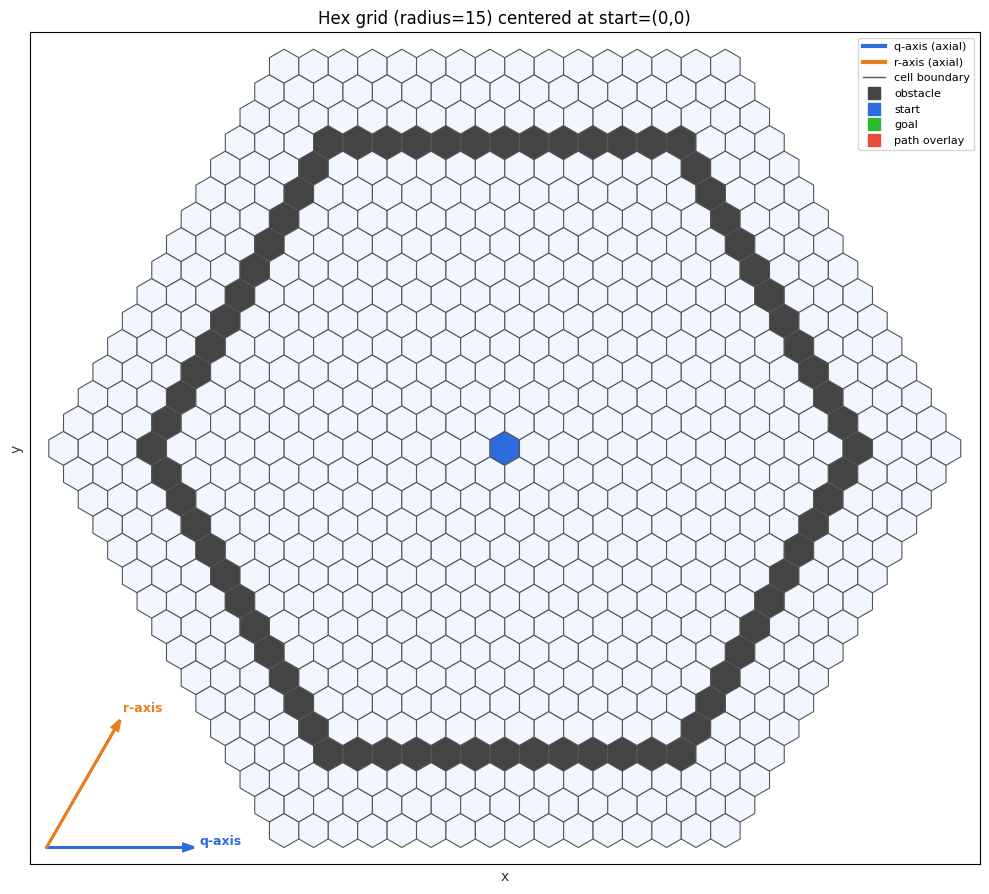

In [10]:
obs2 = get_neighbors_at_radius(start, 12)
plot_hex_grid(obs2, start, 15, figsize=(10,10), show_coords=False)